In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import spikeinterface as si
import spikeinterface.extractors as se
import cmap

from tools.io import load_units_metadata, load_probe


plt.style.use('dark_background')
heatmap = cmap.Colormap('seaborn:vlag').to_matplotlib()

data_path = Path(r"/Volumes/fsmresfiles/Basic_Sciences/Phys/SenzaiLab/Elissa_Belluccini/Kilosort/Mouse10_20260210_795to2220/ProbeA")
output_path = Path('/Users/iii9781/senzailab/tools/data')
fs = 30000

def plot_shank_templates(
    template: np.ndarray,
    probe: pd.DataFrame,
    unit_idx: int,
    output_path: str | Path | None = None,
    ms_before: float = 1.0,
    ms_after: float = 2.0,
    heatmap: str = 'viridis'
    ):

    fig, axs = plt.subplots(2, 5, figsize=(20, 5), sharex=False, sharey=False,
                            gridspec_kw={'height_ratios': [1, 0.05], 'wspace': 0.4, 'hspace': 0.4}
                            )
    fig.suptitle(f'Unit {unit_idx}')
    shanks = np.unique(probe['shank_ids']).astype(int)
    
    for shank in shanks: # 4 shanks
        shank_mask = probe['shank_ids'] == shank
        shank_sorted_idx = probe[shank_mask].sort_values('depth').index.values

        depth = probe[shank_mask]['depth'].values
        depth_min, depth_max = depth.min(), depth.max()


        axs[0, shank].set_title(f'Shank {shank}')
        im = axs[0, shank].imshow(
                template[:, shank_sorted_idx].T,
                aspect='auto',
                origin='lower',
                interpolation='none',
                cmap=heatmap,
                extent=[-ms_before, ms_after, depth_min, depth_max]
            )
        axs[0, shank].axvline(0, color='green', linestyle='--', alpha=0.5, linewidth=0.6)
        fig.colorbar(im, cax=axs[1, shank], orientation='horizontal')
    
    axs[0, 4].set_title('All channels (Shank-wise depth sorted)')
    im = axs[0, 4].imshow(template[:, probe.index.values].T, aspect='auto', origin='lower', interpolation='none', cmap=heatmap, extent=[-ms_before, ms_after, 0, 384])
    axs[0, 4].axvline(0, color='green', linestyle='--', alpha=0.5, linewidth=0.6)
    fig.colorbar(im, cax=axs[1, 4], orientation='horizontal')

    if output_path:
        plt.savefig(output_path, dpi=320)
        plt.close(fig)
        return None
    
    return fig, axs

In [2]:
units = load_units_metadata(data_path / 'kilosort', sorted = False)
probe = load_probe(data_path / 'kilosort', sorted = False)
probe

,x,depth,shank_ids
0,250.0,2160.0,1
1,782.0,1440.0,3
2,750.0,1455.0,3
3,282.0,2175.0,1
4,250.0,2190.0,1
...,...,...,...
379,282.0,1395.0,1
380,250.0,1410.0,1
381,32.0,2130.0,0
382,0.0,2145.0,0


Sorting analyzer

In [4]:
processing_dir = output_path / 'postprocess'

if processing_dir.exists():
    pp = si.load_sorting_analyzer(processing_dir, load_extensions=False)
else:
    rec = si.load(str(data_path / 'concat'))
    sorting = se.read_kilosort(data_path / 'kilosort').select_units(units['cluster_id'].values)
    pp = si.create_sorting_analyzer(
        sorting=sorting,
        recording=rec,
        sparse=False,
        folder=processing_dir,
        format='binary_folder',
        overwrite=False,
    )

    job_kwargs = dict(n_jobs=-1, chunk_duration="2s", progress_bar=True)

    compute_dict = {
        'random_spikes': {'method': 'uniform', 'max_spikes_per_unit': 5000},
        'waveforms': {'ms_before': 1.0, 'ms_after': 2.0},
        'templates': {'operators': ["average", "std"]},
        'noise_levels': {},
        'spike_amplitudes': {}
    }

    pp.compute(compute_dict, **job_kwargs)

template_ext = pp.get_extension('templates')

ms_before = template_ext.params['ms_before']
ms_after = template_ext.params['ms_after']
templates = template_ext.get_templates()

Unit positions

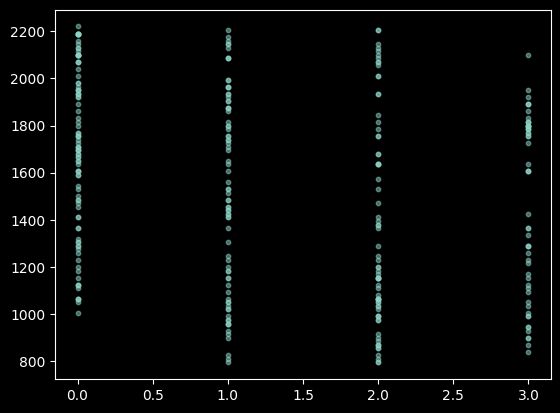

In [5]:
plt.scatter(units['shank_ids'], units['depth'], s=10, alpha=0.5)

Template analysis

In [ ]:
results_dir = output_path / 'templates'
results_dir.mkdir(exist_ok=True, parents=True)

for idx, unit_row in units.iterrows():
    unit_id = unit_row['cluster_id']
    template = template_ext.get_unit_template(unit_id)
    template = template - template.mean(axis=0)
    plot_shank_templates(template, probe, unit_id, output_path=results_dir / f'unit_{unit_id}_template.png', heatmap=heatmap)
    break

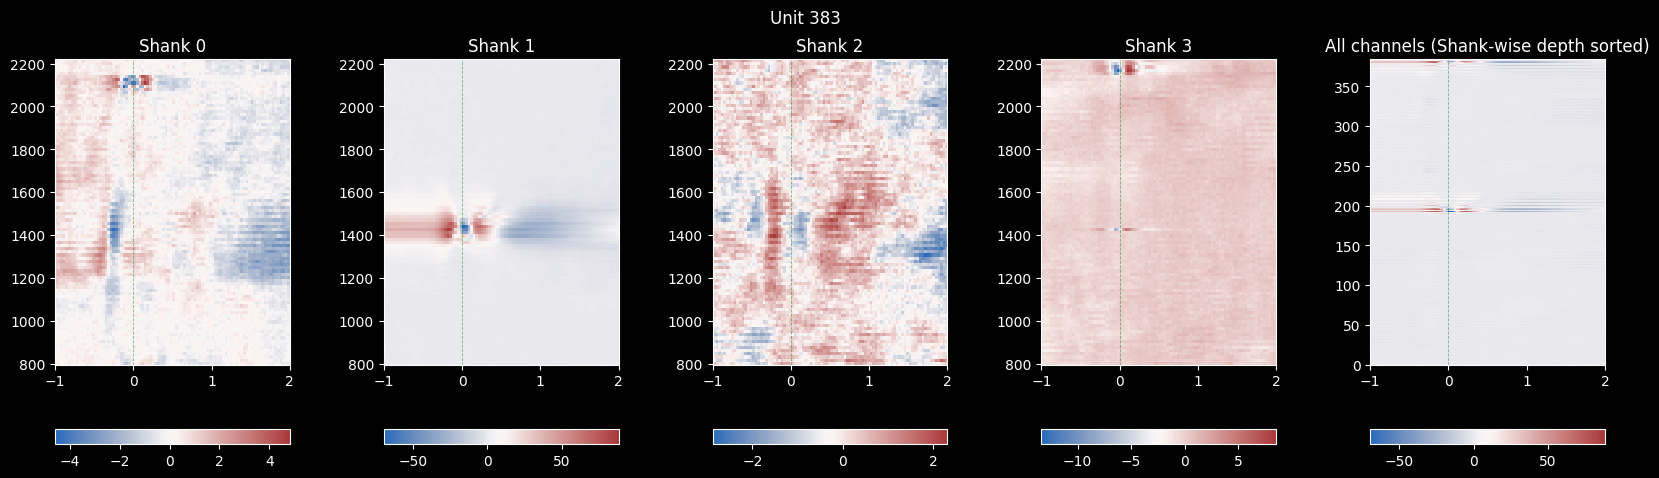

In [6]:
uid = 383
template = template_ext.get_unit_template(uid)
template = template - np.median(template, axis=0)
plot_shank_templates(template, probe, uid, heatmap=heatmap)
plt.show()

In [15]:
unit_row = units[units['cluster_id'] == uid]
unit_row

,cluster_id,Amplitude,ContamPct,KSLabel,amp,ch,depth,fr,group,n_spikes,shank_ids
379,383,11.8,9.3,good,754.970947,192,1440.0,22.346051,good,813221,1.0


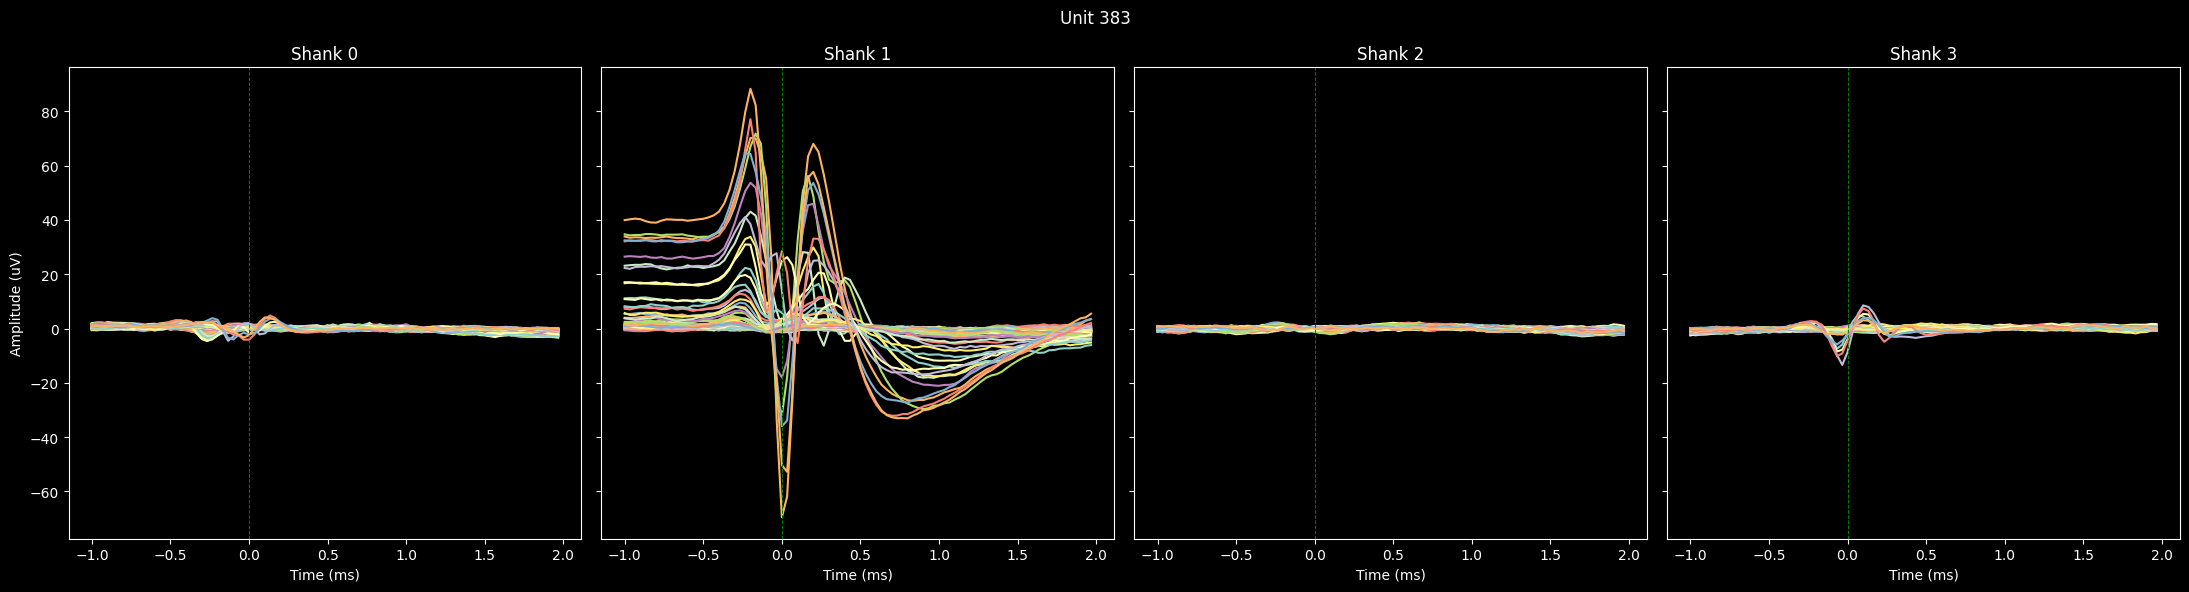

In [178]:
unit_row = units[units['cluster_id'] == uid]
shanks = np.unique(probe['shank_ids']).astype(int)
t = np.arange(template.shape[0]) / fs * 1000 - ms_before

fig, axs = plt.subplots(1, len(shanks), figsize=(22, 6), sharex=True, sharey=True)

for i, shank in enumerate(shanks):
    shank_mask = probe['shank_ids'] == shank

    shank_idx = probe[shank_mask].index.values
    y = template[:, shank_idx]

    axs[i].plot(t, y)
    axs[i].set_title(f'Shank {shank}')
    axs[i].set_xlabel('Time (ms)')
    axs[i].axvline(0, color='green', linestyle='--', alpha=1, linewidth=0.7)

    if i == 0:
        axs[i].set_ylabel('Amplitude (uV)')
    
plt.suptitle(f'Unit {uid}')
plt.tight_layout()
plt.show()

1. Number of positive/negative peaks

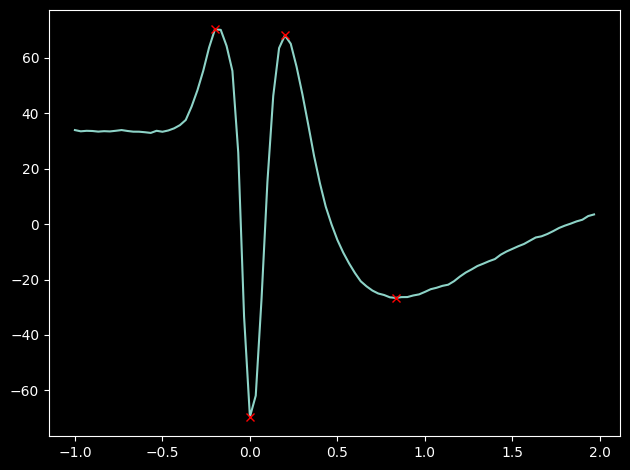

In [83]:
from scipy.signal import find_peaks

ch = unit_row['ch']
sig = np.squeeze(template[:, ch])
prominence_thresh = 0.3

min_prominence = prominence_thresh * np.abs(sig).max()
peaks, properties = find_peaks(np.abs(sig), prominence=min_prominence)

num_pos_peaks = np.sum(sig[peaks] > 0)
num_neg_peaks = np.sum(sig[peaks] < 0)

plt.plot(t, sig)
plt.plot(t[peaks], sig[peaks], 'x', color='red')
plt.tight_layout()
plt.show()

2. Spread

In [145]:
from scipy.ndimage import gaussian_filter1d

spread_thresh = 0.2
spread_smooth_um = 20

depth = probe.sort_values('depth')['depth']
depth_sorted_idx = depth.index.values
mm = np.ptp(template, axis=0)[depth_sorted_idx]

spread_sigma = spread_smooth_um / np.median(np.diff(np.unique(probe['depth'])))
mm = gaussian_filter1d(mm, spread_sigma)
mm = mm / mm.max()

channels = mm > spread_thresh
channels_idx = np.where(channels)[0]
lo, hi = channels_idx[0], channels_idx[-1]

spread = max(depth[channels]) - min(depth[channels])
spread

195.0

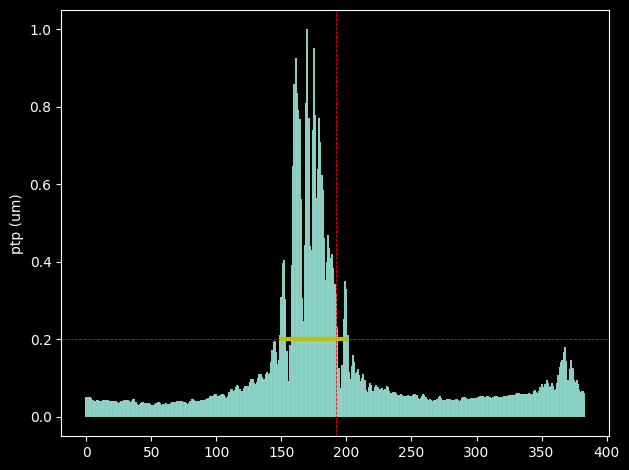

In [146]:
markerline, stemlines, baseline = plt.stem(mm, markerfmt=' ')
stemlines.set_linewidth(1.4)
baseline.set_visible(False)

plt.axvline(unit_row['ch'].item(), c = 'r', linestyle = '--', linewidth=0.6)
plt.axhline(spread_thresh, c = 'g',  linestyle = '--', linewidth=0.6)
plt.hlines(spread_thresh, xmin=lo, xmax=hi, color='y', linewidth=3)
plt.ylabel('ptp (um)')
plt.tight_layout()
plt.show()